In [1]:
%matplotlib inline
import random
import torch
import sys
import os

# Add the d2l-en folder to Python path
sys.path.insert(0, './d2l-en/pytorch')
from d2l import torch as d2l

In [5]:
def synthetic_data(w, b, num_examples):
    # create data y = Xw + b + noise
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X,w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [6]:
print(f"features:{features[0]} \nlabel: {labels[0]}")

features:tensor([-0.7204, -0.1198]) 
label: tensor([3.1603])


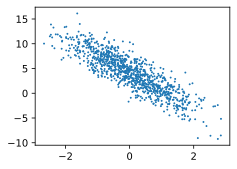

In [7]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [10]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))

    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i+batch_size, num_examples)])  # take minimum because may not have sufficient batch for the last one
        yield features[batch_indices], labels[batch_indices] # yield returns per for loop, instead of returning all at once

batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break


tensor([[ 0.4423, -0.4710],
        [-0.1607,  1.1976],
        [ 0.8694,  0.3262],
        [ 0.1842,  0.9278],
        [-1.5644,  0.2292],
        [ 0.1658, -0.3088],
        [ 0.4801, -0.9988],
        [-0.7451,  1.3963],
        [-1.3314, -0.5908],
        [ 1.0451,  0.4660]]) 
 tensor([[ 6.6862],
        [-0.1904],
        [ 4.8285],
        [ 1.4352],
        [ 0.2878],
        [ 5.5805],
        [ 8.5579],
        [-2.0313],
        [ 3.5352],
        [ 4.7083]])


initiate model

In [11]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

define model

In [12]:
def linreg(X, w, b):
    return torch.matmul(X, w) + b

define loss function

In [13]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape))**2 / 2
    # reshape is helpful because y_hat might be col vector or row vector, so just to be safe

In [17]:
def sgd(params, lr, batch_size):
    # params includes W and b
    with torch.no_grad():  # disable tracking on gradient while we do operations on the parameters to update them
        # with sets something up at the beginnning and automatically enables after block finished
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [18]:
def net(X, w, b):
    """Linear regression model: y = Xw + b"""
    return torch.matmul(X, w) + b

actual training

In [21]:
lr = 0.03
num_epochs = 3
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)

    # printing to see the loss in each epoch ( the whole set instead of just losses of batches)
    # the code above does calculations for losses in batches
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.000051
epoch 2, loss 0.000051
epoch 3, loss 0.000051
